In [1]:
import pandas as pd
import os
import numpy as np
from matplotlib import pyplot as plt
import backbone as bb
from tqdm import tqdm

#import train_labels dataset
cwd = os.getcwd()
filepath = 'data/train_labels.csv'
df = pd.read_csv(os.path.join(cwd, filepath))

#import train labels dataset using backbone module
file_path_trainlabels, file_path_trainimages, train_labels = bb.init_data()

<AxesSubplot:>

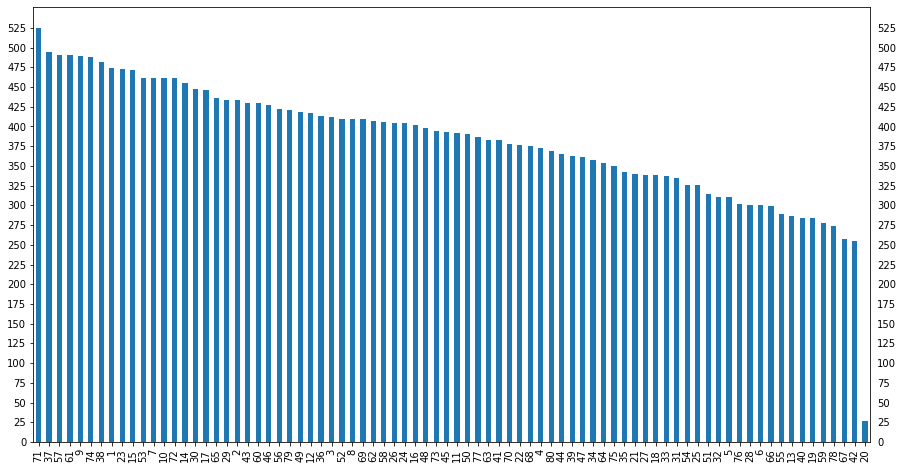

In [2]:
#Check label frequency
train_labels['label'] = train_labels['label'].astype('str')
labels = train_labels['label'].value_counts()

fig = plt.figure()
ax = fig.add_subplot(111)
ax.tick_params(labelright=True)
labels.plot(kind='bar', figsize=(15,8), yticks=np.arange(0, max(labels)+1, 25))

# Splitting the Data and Data Augmentation

In [3]:
from keras.preprocessing.image import ImageDataGenerator

HEIGHT = 256
WIDTH = 256

#Data augmentation for the training set:
train_datagen = ImageDataGenerator(validation_split=0.2,
                                       rotation_range=2, 
                                       horizontal_flip=True,
                                       zoom_range=.1)

#Pre-processing the validation set (without data augmentation):
val_datagen = ImageDataGenerator(validation_split=0.2)

#Initiate a generator for the test set
test_datagen = ImageDataGenerator()

In [4]:
#Train dataset generator
train_generator=train_datagen.flow_from_dataframe(dataframe=train_labels, #dataframe with the image names and labels
                                            directory=file_path_trainimages, #filepath images
                                            x_col='img_name',
                                            y_col='label',
                                            subset='training',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42, #how the data is randomized
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest', #interpolation method for resizing images
                                            target_size=(HEIGHT, WIDTH))

Found 24490 validated image filenames belonging to 80 classes.


In [5]:
#Validation dataset generator
val_generator=val_datagen.flow_from_dataframe(dataframe=train_labels,
                                            directory=file_path_trainimages,
                                            x_col='img_name',
                                            y_col='label',
                                            subset='validation',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=True,
                                            class_mode='categorical',
                                            class_names=None,
                                            interpolation='nearest',
                                            target_size=(HEIGHT, WIDTH))

Found 6122 validated image filenames belonging to 80 classes.


In [6]:
file_path_testimages, file_path_testlabels, test_labels = bb.get_test_paths()

#Test dataset generator
test_generator=test_datagen.flow_from_dataframe(dataframe=test_labels,
                                            directory=file_path_testimages,
                                            x_col='img_name',
                                            y_col='label',
                                            color_mode="rgb",
                                            batch_size=32,
                                            seed=42,
                                            shuffle=False,
                                            class_mode=None,
                                            class_names=None,
                                            interpolation='nearest',
                                            target_size=(HEIGHT, WIDTH))

Found 7653 validated image filenames.


In [7]:
#Check shapes of batches for both x and y. 
#Format x: (batch size, height, width, channels)
#Format y: (batch size, number of possible labels (one-hot encoded))
print(f'shape of batch in x_train: {train_generator.next()[0].shape}')
print(f'shape of batch in y_train: {train_generator.next()[1].shape}')

shape of batch in x_train: (32, 256, 256, 3)
shape of batch in y_train: (32, 80)


<AxesSubplot:>

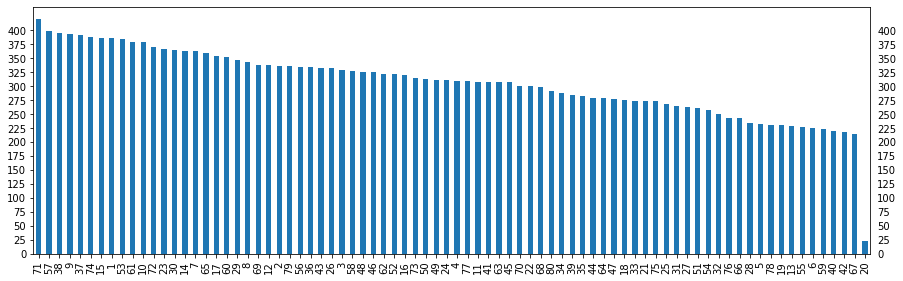

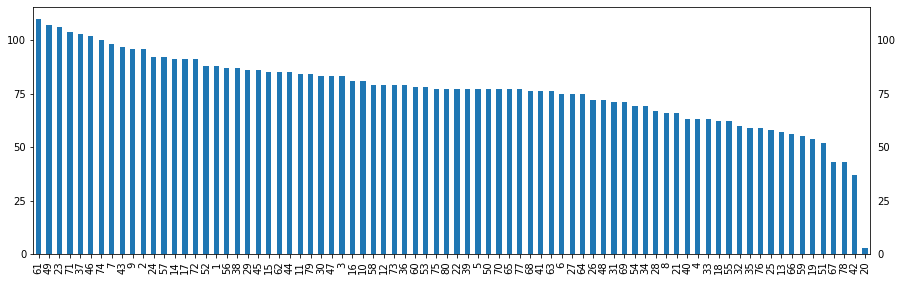

In [8]:
#Check that the training and validation split has split the data proportionally by label
dict_t = {str(v) : str(k) for k, v in train_generator.class_indices.items()}
dict_v = {str(v) : str(k) for k, v in val_generator.class_indices.items()}

clss = pd.Series(train_generator.classes).astype('str')
clss = clss.replace(dict_t)
clss = clss.value_counts()

fig = plt.figure()
ax = fig.add_subplot(211)
ax.tick_params(labelright=True)
clss.plot(kind='bar', figsize=(15,10), yticks=np.arange(0, max(clss)+1, 25))

clss2 = pd.Series(val_generator.classes).astype('str')
clss2 = clss2.replace(dict_v)
clss2 = clss2.value_counts()

fig = plt.figure()
ax = fig.add_subplot(212)
ax.tick_params(labelright=True)
clss2.plot(kind='bar', figsize=(15,10), yticks=np.arange(0, max(clss2)+1, 25))

# Balancing the Dataset

## 2 approaches: setting weights to labels and over-sampling in a balanced way

In [10]:
#Balancing dataset by setting weights to the labels
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
           'balanced',
            np.unique(train_generator.classes), 
            train_generator.classes)

#then use:    model.fit_generator(train_generator, class_weight=class_weights)

In [11]:
#Dataframe created with the labels and the weights given (just to check)
weights_df = pd.DataFrame()
weights_df['label'] = dict_t.values()
weights_df['weights'] = class_weights
print(f'Max weight (minority class): {weights_df[weights_df["label"] == "20"].values} label, weight')
print(f'Min weight (majority class): {weights_df[weights_df["label"] == "71"].values} label, weight')

Max weight (minority class): [['20' 12.755208333333334]] label, weight
Min weight (majority class): [['71' 0.7271377672209026]] label, weight


### Note that the following approach (over-sampling) does not work yet

In [19]:
#Balancing dataset by over-sampling (data has to be imported in a different way)
from imblearn.over_sampling import RandomOverSampler
from tensorflow import keras
from imblearn.tensorflow import balanced_batch_generator

def balancer(x, y, datagen, batch_size):
    datagen.fit(x)
    generator, steps_per_epoch = balanced_batch_generator(x, y, sampler=RandomOverSampler(),
                                                                   batch_size=batch_size, random_state=42)
    
    x_batch, y_batch = generator.next()
    return datagen.flow(x_batch, y_batch, batch_size=batch_size).next()

In [ ]:
X_train = []
for label in tqdm(train_labels['img_name']):
    X_train.append(np.expand_dims(plt.imread(file_path_trainimages + label), axis=0))
d = {'images':X_train,'labels':train_labels['label']}
df = pd.DataFrame(d)

In [ ]:
from keras.utils.data_utils import Sequence
from imblearn.over_sampling import RandomOverSampler
from imblearn.tensorflow import balanced_batch_generator

class BalancedDataGenerator(Sequence):
    """ImageDataGenerator + RandomOversampling"""
    def __init__(self, x, y, datagen, batch_size=32):
        self.datagen = datagen
        self.batch_size = min(batch_size, x.shape[0])
        datagen.fit(x)
        self.gen, self.steps_per_epoch = balanced_batch_generator(x.reshape(x.shape[0], -1), y, sampler=RandomOverSampler(), batch_size=self.batch_size, keep_sparse=True)
        self._shape = (self.steps_per_epoch * batch_size, *x.shape[1:])
        
    def __len__(self):
        return self.steps_per_epoch

    def __getitem__(self, idx):
        x_batch, y_batch = self.gen.__next__()
        x_batch = x_batch.reshape(-1, *self._shape[1:])
        return self.datagen.flow(x_batch, y_batch, batch_size=self.batch_size).next()

In [ ]:
datagen = ImageDataGenerator()
balanced_train = BalancedDataGenerator(df['images'].values, str(df['labels'].values), datagen, 32)

In [ ]:
img = plt.imread(os.path.join(cwd, 'data/train_set/train_set/train_1.jpg'))
img1 = np.expand_dims(img, axis=0)
np.expand_dims(df['images'].values[0], axis=0).shape
df['images'].values[0].shape